<a href="https://colab.research.google.com/github/GU-DPM/DPM_DB/blob/main/oldCode/Explore_DPM_Misspecification_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## setup

In [ ]:
# set up bq environment
from google.colab import auth
from google.colab import data_table
from google.cloud import bigquery
data_table.enable_dataframe_formatter()
auth.authenticate_user()

# setup project info - email matthew.mccoy@georgetown.edu about access
from google.colab import drive
drive.mount('/content/drive')

project = 'mccoylab' # Project ID inserted based on the query results selected to explore
location = 'us-east1' # Location inserted based on the query results selected to explore
client = bigquery.Client(project=project, location=location)

# install lifelines for KMplots and hazard ratios
!pip install lifelines

Mounted at /content/drive
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=df0a9768a26ed906427b01ca4195adcd0d1e535b450bc61b0d499e06fabd22de
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:

import pandas as pd
from google.cloud import bigquery

def add_benefit_columns(df, min_survival_days=60, min_percent_benefit=25):
    """
    Adds benefit columns to the dataframe based on survival days and percent benefit.

    Parameters:
    df (pd.DataFrame): The input dataframe.
    min_survival_days (int): Minimum survival days. Defaults to 60.
    min_percent_benefit (float): Minimum percent benefit. Defaults to 25.

    Returns:
    pd.DataFrame: The dataframe with added benefit columns.
    """
    # Calculate benefit_DPM
    df['benefitDays_DPM'] = df['Survival_DPM'] - df['Survival_CPM']
    df['benefitPercent_DPM'] = (df['Survival_DPM'] - df['Survival_CPM']) / df['Survival_CPM']
    df['benefit_DPM'] = (df['Survival_DPM'] - df['Survival_CPM'] >= min_survival_days) & \
                        ((df['Survival_DPM'] - df['Survival_CPM']) / df['Survival_CPM'] >= min_percent_benefit / 100)

    return df

def fetch_ecsurvival(categories=None, limit=25, dosage_filter=None, param_filter=None):
    """
    Fetch a random sample of rows from ECsurvival_CPM_under_4_years joined with simParamOutput
    and simTrajectories for multiple dosage steps, with optional filters on dosage and parameter ranges.
    Adds a column 'misspecification_rate' with value 'baseline' as the first column.
    """
    allowed = {"both_diff", "first_same_only", "second_same_only", "both_same"}
    if not categories:
        categories = list(allowed)

    invalid = set(categories) - allowed
    if invalid:
        raise ValueError(f"Invalid categories: {invalid}. Allowed: {', '.join(sorted(allowed))}")

    # Build dosage filter conditions
    dosage_conditions = []
    dosage_params = []
    if dosage_filter:
        for col, val in dosage_filter.items():
            if col not in {"Drug1_Step1_CPM", "Drug1_Step2_CPM", "Drug1_Step1_DPM", "Drug1_Step2_DPM"}:
                raise ValueError(f"Invalid dosage column: {col}")
            if val not in {0, 0.5, 1}:
                raise ValueError(f"Invalid dosage value for {col}: {val}. Must be 0, 0.5, or 1.")
            dosage_conditions.append(f"traj.{col} = @{col}")
            dosage_params.append(bigquery.ScalarQueryParameter(col, "FLOAT64", val))

    # Build parameter range filter conditions
    param_conditions = []
    param_params = []
    if param_filter:
        for col, bounds in param_filter.items():
            if not isinstance(bounds, dict):
                raise ValueError(f"Bounds for {col} must be a dict with optional 'min' and 'max'.")
            if "min" in bounds and bounds["min"] is not None:
                param_conditions.append(f"sp.{col} >= @{col}_min")
                param_params.append(bigquery.ScalarQueryParameter(f"{col}_min", "FLOAT64", bounds["min"]))
            if "max" in bounds and bounds["max"] is not None:
                param_conditions.append(f"sp.{col} <= @{col}_max")
                param_params.append(bigquery.ScalarQueryParameter(f"{col}_max", "FLOAT64", bounds["max"]))

    # Combine all conditions
    extra_conditions = ""
    if dosage_conditions or param_conditions:
        extra_conditions = " AND " + " AND ".join(dosage_conditions + param_conditions)

    query = f"""
        WITH traj AS (
          SELECT
            Parameter_ID,
            ANY_VALUE(CASE WHEN Strategy_name = 'CPM' AND timepoint = 0 THEN Drug1_dosage END) AS Drug1_Step1_CPM,
            ANY_VALUE(CASE WHEN Strategy_name = 'CPM' AND timepoint = 45 THEN Drug1_dosage END) AS Drug1_Step2_CPM,
            ANY_VALUE(CASE WHEN Strategy_name = 'DPM' AND timepoint = 0 THEN Drug1_dosage END) AS Drug1_Step1_DPM,
            ANY_VALUE(CASE WHEN Strategy_name = 'DPM' AND timepoint = 45 THEN Drug1_dosage END) AS Drug1_Step2_DPM
          FROM `mccoylab.DPM_ECeast.simTrajectories`
          WHERE Strategy_name IN ('CPM','DPM') AND timepoint IN (0,45)
          GROUP BY Parameter_ID
        )
        SELECT
          ec.Parameter_ID,
          ec.Survival_CPM,
          ec.Survival_DPM,
          ec.EC_category,
          traj.Drug1_Step1_CPM,
          traj.Drug1_Step2_CPM,
          traj.Drug1_Step1_DPM,
          traj.Drug1_Step2_DPM,
          sp.S_pop,
          sp.R1_pop,
          sp.R2_pop,
          sp.R12_pop,
          sp.g0,
          sp.S_cell_sensitivity_D1,
          sp.S_cell_sensitivity_D2,
          sp.R1_cell_sensitivity_D1,
          sp.R1_cell_sensitivity_D2,
          sp.R2_cell_sensitivity_D1,
          sp.R2_cell_sensitivity_D2,
          sp.R12_cell_sensitivity_D1,
          sp.R12_cell_sensitivity_D2,
          sp.S_transition_to_R1,
          sp.S_transition_to_R2,
          sp.R1_transition_to_R12,
          sp.R2_transition_to_R12
        FROM `mccoylab.DPM_ECeast.ECsurvival_CPM_under_4_years` AS ec
        JOIN `mccoylab.DPM_ECeast.simParamOutput` AS sp
          ON ec.Parameter_ID = sp.Parameter_ID
        LEFT JOIN traj
          ON ec.Parameter_ID = traj.Parameter_ID
        WHERE ec.EC_category IN UNNEST(@categories){extra_conditions}
              AND sp.S_cell_sensitivity_D1 > 0.2 * sp.g0
              AND sp.S_cell_sensitivity_D2 > 0.2 * sp.g0
              AND sp.R12_cell_sensitivity_D1 < sp.g0
              AND sp.R12_cell_sensitivity_D2 < sp.g0
        ORDER BY RAND()
        LIMIT {limit}
    """

    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ArrayQueryParameter("categories", "STRING", categories),
            *dosage_params,
            *param_params
        ]
    )

    result = client.query(query, job_config=job_config).result()
    df = result.to_dataframe()
    df = add_benefit_columns(df)
    # Add misspecification_rate column as first column
    df.insert(0, "misspecification_rate", "baseline")

    return df

def fetch_misspecification_details(param_ids):
    """
    Build a dataframe for the misspecification scenario using Parameter_IDs from a prior sample.
    Joins ECsurvival, simTrajectories (pivoted dosage steps), and simParameters_output
    from the DPM_MISS dataset. Dosage columns are matched on the same misspecification_rate.

    Parameters
    ----------
    param_ids : list
        List of Parameter_ID values from the first query (ints or strings).

    Returns
    -------
    pandas.DataFrame
    """
    if not param_ids or not isinstance(param_ids, list):
        raise ValueError("param_ids must be a non-empty list of Parameter_ID values.")

    # Determine parameter type (INT64 vs STRING) for safety
    param_type = "INT64" if all(isinstance(x, int) for x in param_ids) else "STRING"

    # Initialize a client for the DPM_MISS dataset's specific location
    #client_miss = bigquery.Client(project='mccoylab', location='us-east1')

    query = f"""
        -- Trajectories pivoted to dosage step columns, aligned to the same misspecification_rate
        WITH traj AS (
          SELECT
            t.Parameter_ID,
            t.misspecification_rate,
            ANY_VALUE(CASE WHEN t.Strategy_name = 'CPM' AND t.timepoint = 0  THEN t.Drug1_dosage END) AS Drug1_Step1_CPM,
            ANY_VALUE(CASE WHEN t.Strategy_name = 'CPM' AND t.timepoint = 45 THEN t.Drug1_dosage END) AS Drug1_Step2_CPM,
            ANY_VALUE(CASE WHEN t.Strategy_name = 'DPM' AND t.timepoint = 0  THEN t.Drug1_dosage END) AS Drug1_Step1_DPM,
            ANY_VALUE(CASE WHEN t.Strategy_name = 'DPM' AND t.timepoint = 45 THEN t.Drug1_dosage END) AS Drug1_Step2_DPM
          FROM `mccoylab.DPM_MISS.simTrajectories` AS t
          -- JOIN `mccoylab.DPM_MISS.simParameters_output` AS sp
          --   ON t.Parameter_ID = sp.Parameter_ID
          WHERE t.Strategy_name IN ('CPM','DPM')
            AND t.timepoint IN (0, 45)
            AND t.Parameter_ID IN UNNEST(@param_ids)
          GROUP BY t.Parameter_ID, t.misspecification_rate
        )
        SELECT
          sp.misspecification_rate,              -- first column (from simParameters_output)
          ec.Parameter_ID,
          ec.Survival_CPM,
          ec.Survival_DPM,
          ec.EC_category,
          traj.Drug1_Step1_CPM,
          traj.Drug1_Step2_CPM,
          traj.Drug1_Step1_DPM,
          traj.Drug1_Step2_DPM,
          sp.S_pop,
          sp.R1_pop,
          sp.R2_pop,
          sp.R12_pop,
          sp.g0,
          sp.S_cell_sensitivity_D1,
          sp.S_cell_sensitivity_D2,
          sp.R1_cell_sensitivity_D1,
          sp.R1_cell_sensitivity_D2,
          sp.R2_cell_sensitivity_D1,
          sp.R2_cell_sensitivity_D2,
          sp.R12_cell_sensitivity_D1,
          sp.R12_cell_sensitivity_D2,
          sp.S_transition_to_R1,
          sp.S_transition_to_R2,
          sp.R1_transition_to_R12,
          sp.R2_transition_to_R12
        FROM `mccoylab.DPM_MISS.ECsurvival` AS ec
        JOIN `mccoylab.DPM_MISS.simParameters_output` AS sp
          ON ec.Parameter_ID = sp.Parameter_ID
          AND ec.misspecification_rate = sp.misspecification_rate
        LEFT JOIN traj
          ON ec.Parameter_ID = traj.Parameter_ID
         AND ec.misspecification_rate = traj.misspecification_rate
        WHERE ec.Parameter_ID IN UNNEST(@param_ids)
    """

    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ArrayQueryParameter("param_ids", param_type, param_ids),
        ]
    )

    result = client.query(query, job_config=job_config).result()
    df = result.to_dataframe()
    df = add_benefit_columns(df)
    #df = df.drop_duplicates()

    return df

def fetch_misspecification_details(param_ids):
    """
    Build a dataframe for the misspecification scenario using Parameter_IDs from a prior sample.
    Joins ECsurvival, simTrajectories (pivoted dosage steps), and simParameters_output
    from the DPM_MISS dataset. Dosage columns are matched on the same misspecification_rate.

    Parameters
    ----------
    param_ids : list
        List of Parameter_ID values from the first query (ints or strings).

    Returns
    -------
    pandas.DataFrame
    """
    if not param_ids or not isinstance(param_ids, list):
        raise ValueError("param_ids must be a non-empty list of Parameter_ID values.")

    # Determine parameter type (INT64 vs STRING) for safety
    param_type = "INT64" if all(isinstance(x, int) for x in param_ids) else "STRING"

    # Initialize a client for the DPM_MISS dataset's specific location
    #client_miss = bigquery.Client(project='mccoylab', location='us-east1')

    query = f"""
        -- Trajectories pivoted to dosage step columns, aligned to the same misspecification_rate
        WITH traj AS (
          SELECT
            t.Parameter_ID,
            t.misspecification_rate,
            ANY_VALUE(CASE WHEN t.Strategy_name = 'CPM' AND t.timepoint = 0  THEN t.Drug1_dosage END) AS Drug1_Step1_CPM,
            ANY_VALUE(CASE WHEN t.Strategy_name = 'CPM' AND t.timepoint = 45 THEN t.Drug1_dosage END) AS Drug1_Step2_CPM,
            ANY_VALUE(CASE WHEN t.Strategy_name = 'DPM' AND t.timepoint = 0  THEN t.Drug1_dosage END) AS Drug1_Step1_DPM,
            ANY_VALUE(CASE WHEN t.Strategy_name = 'DPM' AND t.timepoint = 45 THEN t.Drug1_dosage END) AS Drug1_Step2_DPM
          FROM `mccoylab.DPM_MISS.simTrajectories` AS t
          -- JOIN `mccoylab.DPM_MISS.simParameters_output` AS sp
          --   ON t.Parameter_ID = sp.Parameter_ID
          WHERE t.Strategy_name IN ('CPM','DPM')
            AND t.timepoint IN (0, 45)
            AND t.Parameter_ID IN UNNEST(@param_ids)
          GROUP BY t.Parameter_ID, t.misspecification_rate
        )
        SELECT
          sp.misspecification_rate,              -- first column (from simParameters_output)
          ec.Parameter_ID,
          ec.Survival_CPM,
          ec.Survival_DPM,
          ec.EC_category,
          traj.Drug1_Step1_CPM,
          traj.Drug1_Step2_CPM,
          traj.Drug1_Step1_DPM,
          traj.Drug1_Step2_DPM,
          sp.S_pop,
          sp.R1_pop,
          sp.R2_pop,
          sp.R12_pop,
          sp.g0,
          sp.S_cell_sensitivity_D1,
          sp.S_cell_sensitivity_D2,
          sp.R1_cell_sensitivity_D1,
          sp.R1_cell_sensitivity_D2,
          sp.R2_cell_sensitivity_D1,
          sp.R2_cell_sensitivity_D2,
          sp.R12_cell_sensitivity_D1,
          sp.R12_cell_sensitivity_D2,
          sp.S_transition_to_R1,
          sp.S_transition_to_R2,
          sp.R1_transition_to_R12,
          sp.R2_transition_to_R12
        FROM `mccoylab.DPM_MISS.ECsurvival` AS ec
        JOIN `mccoylab.DPM_MISS.simParameters_output` AS sp
          ON ec.Parameter_ID = sp.Parameter_ID
          AND ec.misspecification_rate = sp.misspecification_rate
        LEFT JOIN traj
          ON ec.Parameter_ID = traj.Parameter_ID
         AND ec.misspecification_rate = traj.misspecification_rate
        WHERE ec.Parameter_ID IN UNNEST(@param_ids)
    """

    job_config = bigquery.QueryJobConfig(
        query_parameters=[
            bigquery.ArrayQueryParameter("param_ids", param_type, param_ids),
        ]
    )

    result = client.query(query, job_config=job_config).result()
    df = result.to_dataframe()
    df = add_benefit_columns(df)
    #df = df.drop_duplicates()

    return df
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter

def fetch_trial_arm(categories=None, limit=25, dosage_filter=None, param_filter=None):
    baseline_df = fetch_ecsurvival(categories, limit, dosage_filter, param_filter)
    param_ids = baseline_df["Parameter_ID"].tolist()
    misspec_df = fetch_misspecification_details(param_ids)
    df = pd.concat([baseline_df, misspec_df], ignore_index=True)
    df = df.sort_values(by=['Parameter_ID', 'misspecification_rate'], ascending=[True, True]).reset_index(drop=True)
    return df

def plot_km_two_arms(
    dpm_arm: pd.DataFrame,
    cpm_arm: pd.DataFrame,
    time_col_d: str = "Survival_DPM",
    time_col_c: str = "Survival_CPM",
    event_col_d: str | None = None,
    event_col_c: str | None = None,
    arm_labels: tuple[str, str] = ("DPM", "CPM"),
    figsize: tuple[int, int] = (8, 6),
    ci: bool = True
):
    """
    Plot Kaplan–Meier survival curves for two arms.

    Parameters
    ----------
    dpm_arm, cpm_arm : pd.DataFrame
        DataFrames for the two arms.
    time_col_d, time_col_c : str
        Column names containing survival time in DAYS.
    event_col_d, event_col_c : str or None
        Column names for event indicators (1=event, 0=censored).
        If None, assumes all observations are events (uncensored).
    arm_labels : (str, str)
        Labels for the arms in the plot legend.
    figsize : (int, int)
        Figure size.
    ci : bool
        Whether to display confidence intervals.

    Returns
    -------
    matplotlib.axes.Axes
        The Axes object with the KM plot.
    """
    # Prepare series
    T_d = dpm_arm[time_col_d].astype(float)
    E_d = dpm_arm[event_col_d].astype(int) if event_col_d else pd.Series([1] * len(T_d), index=T_d.index)

    T_c = cpm_arm[time_col_c].astype(float)
    E_c = cpm_arm[event_col_c].astype(int) if event_col_c else pd.Series([1] * len(T_c), index=T_c.index)

    # Fit KM
    kmf_d = KaplanMeierFitter(label=arm_labels[0])
    kmf_c = KaplanMeierFitter(label=arm_labels[1])

    fig, ax = plt.subplots(figsize=figsize)
    kmf_d.fit(T_d, event_observed=E_d)
    kmf_d.plot_survival_function(ax=ax, ci_show=ci)

    kmf_c.fit(T_c, event_observed=E_c)
    kmf_c.plot_survival_function(ax=ax, ci_show=ci)

    ax.set_title("Kaplan–Meier Survival Curves")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Survival probability")
    ax.grid(True, alpha=0.3)

    # Optional: number at risk table (lifelines has built-in helpers, but kept minimal here)
    return ax



def calc_hazard_ratio_two_arms(
    dpm_arm: pd.DataFrame,
    cpm_arm: pd.DataFrame,
    arm_id: str | None = None,
    file_path: str | None = None,
    time_col_dpm: str = "Survival_DPM",
    time_col_cpm: str = "Survival_CPM",
    event_col_dpm: str | None = None,  # e.g., "Event_DPM" (1=event, 0=censored)
    event_col_cpm: str | None = None,  # e.g., "Event_CPM" (1=event, 0=censored)
):
    """
    Fit Cox PH models comparing:
      1) Survival_CPM vs Survival_DPM (arm indicator: 1=DPM, 0=CPM)
      2) Survival_CPM vs Survival_DPMtrial (if 'Survival_DPMtrial' exists in dpm_arm)

    Parameters
    ----------
    dpm_arm, cpm_arm : pd.DataFrame
        DataFrames for each arm.
    arm_id : str or None
        Optional label for outputs.
    file_path : str or None
        If provided and file exists, print its content and return.
        Otherwise, save output there after computation.
    time_col_dpm : str
        Column name in dpm_arm for time in days (default 'Survival_DPM').
    time_col_cpm : str
        Column name in cpm_arm for time in days (default 'Survival_CPM').
    event_col_dpm, event_col_cpm : str or None
        Event indicator columns (1=event, 0=censored). If None, assumes all events.

    Returns
    -------
    hr_df : pd.DataFrame
        DataFrame with comparisons, hazard ratios, and arm_id.
    """

    # If a file path is provided and exists, display and exit
    if file_path and os.path.exists(file_path):
        print(f"The file already exists at {file_path}. Loading and printing the content.")
        with open(file_path, 'r') as f:
            print(f.read())
        return

    output_lines = []

    # ---------- Helper: build combined dataset for a two-arm comparison ----------
    def _combine_for_cox(time_series_dpm, time_series_cpm, event_series_dpm=None, event_series_cpm=None):
        df_d = pd.DataFrame({
            "time": pd.to_numeric(time_series_dpm, errors="coerce"),
            "event": (pd.to_numeric(event_series_dpm, errors="coerce") if event_series_dpm is not None else 1),
            "arm": 1  # DPM
        })

        df_c = pd.DataFrame({
            "time": pd.to_numeric(time_series_cpm, errors="coerce"),
            "event": (pd.to_numeric(event_series_cpm, errors="coerce") if event_series_cpm is not None else 1),
            "arm": 0  # CPM
        })

        combined = pd.concat([df_c, df_d], axis=0, ignore_index=True)
        combined = combined.replace([np.inf, -np.inf], np.nan).dropna(subset=["time", "event"])
        combined = combined[combined["time"] >= 0]
        # Ensure integer event dtype with valid 0/1
        combined["event"] = combined["event"].astype(int).clip(lower=0, upper=1)
        return combined

    # ---------- Comparison 1: Survival_CPM vs Survival_DPM ----------
    # Build data
    combined_cpm_dpm = _combine_for_cox(
        dpm_arm[time_col_dpm],
        cpm_arm[time_col_cpm],
        (dpm_arm[event_col_dpm] if event_col_dpm else None),
        (cpm_arm[event_col_cpm] if event_col_cpm else None),
    )

    # Fit Cox model with arm indicator
    cph_cpm_dpm = CoxPHFitter()
    cph_cpm_dpm.fit(
        combined_cpm_dpm,
        duration_col="time",
        event_col="event",
        show_progress=False,
        formula="arm"  # HR for DPM vs CPM
    )

    # Collect outputs
    hdr_text = (
        f"Hazard Ratio between Survival_CPM and Survival_DPM for {arm_id}:"
        if arm_id else
        "Hazard Ratio between Survival_CPM and Survival_DPM:"
    )
    output_lines.append(hdr_text)
    output_lines.append(str(cph_cpm_dpm.summary))

    # Extract HR for arm
    hr_arm = float(cph_cpm_dpm.hazard_ratios_.get("arm", np.nan))

    # ---------- Optional Comparison 2: Survival_CPM vs Survival_DPMtrial ----------
    have_dpmtrial = "Survival_DPMtrial" in dpm_arm.columns
    cph_cpm_dpmtrial = None
    hr_arm_trial = np.nan
    if have_dpmtrial:
        combined_cpm_dpmtrial = _combine_for_cox(
            dpm_arm["Survival_DPMtrial"],
            cpm_arm[time_col_cpm],
            (dpm_arm[event_col_dpm] if event_col_dpm else None),
            (cpm_arm[event_col_cpm] if event_col_cpm else None),
        )
        cph_cpm_dpmtrial = CoxPHFitter()
        cph_cpm_dpmtrial.fit(
            combined_cpm_dpmtrial,
            duration_col="time",
            event_col="event",
            show_progress=False,
            formula="arm"
        )

        hdr_text2 = (
            f"\nHazard Ratio between Survival_CPM and Survival_DPMtrial for {arm_id}:"
            if arm_id else
            "\nHazard Ratio between Survival_CPM and Survival_DPMtrial:"
        )
        output_lines.append(hdr_text2)
        output_lines.append(str(cph_cpm_dpmtrial.summary))

        hr_arm_trial = float(cph_cpm_dpmtrial.hazard_ratios_.get("arm", np.nan))

    # Print combined text
    #print("\n".join(output_lines))

    # Optionally save to file
    if file_path:
        with open(file_path, "w") as f:
            f.write("\n".join(output_lines))
        print(f"The output has been saved to {file_path}.")

    # Debug print (kept from original flow)
    #print("break")
    #print(cph_cpm_dpm.summary)

    # Build tidy HR DataFrame
    rows = [{
        "Comparison": "Survival_CPM vs Survival_DPM",
        "Hazard_Ratio": hr_arm,
        "arm_id": arm_id
    }]


    hr_df = pd.DataFrame(rows)
    return hr_df

def plot_km_two_arms_by_rate(
    dpm_arm: pd.DataFrame,
    cpm_arm: pd.DataFrame,
    rate_col: str = "misspecification_rate",
    time_col_d: str = "Survival_DPM",
    time_col_c: str = "Survival_CPM",
    event_col_d: str | None = None,   # e.g., "Event_DPM" (1=event, 0=censored)
    event_col_c: str | None = None,   # e.g., "Event_CPM" (1=event, 0=censored)
    rate_values: list | None = None,  # exact values to include; if None, uses intersection of unique values
    bins: list | None = None,         # optional bin edges; if provided, grouping uses pd.cut
    min_per_arm: int = 1,             # minimum rows per arm required to plot subset
    ci: bool = True,
    sharey: bool = True,
    palette: tuple[str, str] = ("tab:blue", "tab:orange")
):
    """
    Plot KM curves for DPM vs CPM for each subset defined by `misspecification_rate`.

    Grouping behavior:
    - If `bins` is provided, both arms are binned via pd.cut(rate_col, bins).
    - Else, subsets use exact values. If `rate_values` is None, uses the
      intersection of unique non-null values across both arms.

    Returns
    -------
    fig : matplotlib.figure.Figure
    axes : list[matplotlib.axes.Axes]
    """
    if rate_col not in dpm_arm.columns or rate_col not in cpm_arm.columns:
        raise KeyError(f"`{rate_col}` must exist in both dpm_arm and cpm_arm.")

    dpm = dpm_arm.copy()
    cpm = cpm_arm.copy()

    # Define groups
    if bins is not None:
        dpm["_group"] = pd.cut(dpm[rate_col], bins=bins, include_lowest=True)
        cpm["_group"] = pd.cut(cpm[rate_col], bins=bins, include_lowest=True)
        groups = sorted(
            set(dpm["_group"].dropna().unique()) & set(cpm["_group"].dropna().unique()),
            key=lambda x: (x.left, x.right) if hasattr(x, "left") else x
        )
        def _label(g): return f"{g.left:.3g}–{g.right:.3g}"
    else:
        dpm["_group"] = dpm[rate_col]
        cpm["_group"] = cpm[rate_col]
        groups = rate_values or sorted(
            set(dpm["_group"].dropna().unique()) & set(cpm["_group"].dropna().unique())
        )
        def _label(g): return str(g)

    n = len(groups)
    if n == 0:
        raise ValueError("No overlapping groups found between arms for the given settings.")

    # Subplot layout
    ncols = 2 if n > 1 else 1
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharey=sharey)
    axes = np.atleast_1d(axes).ravel()

    kmf_d = KaplanMeierFitter()
    kmf_c = KaplanMeierFitter()

    plotted = 0
    for i, g in enumerate(groups):
        ax = axes[i]
        d_subset = dpm[dpm["_group"] == g].dropna(subset=[time_col_d])
        c_subset = cpm[cpm["_group"] == g].dropna(subset=[time_col_c])

        if len(d_subset) < min_per_arm or len(c_subset) < min_per_arm:
            ax.set_visible(False)
            continue

        # Prepare times & events
        T_d = pd.to_numeric(d_subset[time_col_d], errors="coerce")
        T_c = pd.to_numeric(c_subset[time_col_c], errors="coerce")
        E_d = (pd.to_numeric(d_subset[event_col_d], errors="coerce").astype(int)
               if event_col_d else pd.Series(1, index=T_d.index))
        E_c = (pd.to_numeric(c_subset[event_col_c], errors="coerce").astype(int)
               if event_col_c else pd.Series(1, index=T_c.index))

        # Fit & plot
        kmf_d.fit(T_d, event_observed=E_d, label="DPM")
        kmf_d.plot_survival_function(ax=ax, ci_show=ci, color=palette[0])

        kmf_c.fit(T_c, event_observed=E_c, label="CPM")
        kmf_c.plot_survival_function(ax=ax, ci_show=ci, color=palette[1])

        ax.set_title(f"KM by {rate_col}: {_label(g)}\nN(DPM)={len(d_subset)}, N(CPM)={len(c_subset)}")
        ax.set_xlabel("Time (days)")
        ax.set_ylabel("Survival probability")
        ax.grid(True, alpha=0.3)
        plotted += 1

    # Hide unused axes
    for j in range(plotted, len(axes)):
        axes[j].set_visible(False)

    fig.tight_layout()
    return fig, list(axes[:plotted])



def calc_hazard_ratio_two_arms_by_rate(
    dpm_arm: pd.DataFrame,
    cpm_arm: pd.DataFrame,
    rate_col: str = "misspecification_rate",
    time_col_dpm: str = "Survival_DPM",
    time_col_cpm: str = "Survival_CPM",
    event_col_dpm: str | None = None,  # e.g., "Event_DPM" (1=event, 0=censored)
    event_col_cpm: str | None = None,  # e.g., "Event_CPM" (1=event, 0=censored)
    arm_id: str | None = None,
    file_path: str | None = None,
    rate_values: list | None = None,   # exact values to include; if None, uses intersection across arms
    bins: list | None = None,          # optional bin edges; if provided, grouping uses pd.cut
    min_per_arm: int = 2,
    include_dpmtrial: bool = True
) -> pd.DataFrame:
    """
    Compute Cox PH hazard ratios within subsets defined by `misspecification_rate`,
    comparing:
      - DPM vs CPM (arm indicator: 1=DPM, 0=CPM)
      - DPMtrial vs CPM (optional, if 'Survival_DPMtrial' exists in dpm_arm)

    Grouping behavior:
    - If `bins` is provided, both arms are binned via pd.cut(rate_col, bins).
    - Else, subsets use exact values. If `rate_values` is None, uses the intersection
      of unique non-null values across both arms.

    Returns
    -------
    hr_df : pd.DataFrame
        One row per subset per comparison with: group, Ns, HR, 95% CI, p, Population_ID.
    """

    # Mirror original behavior: if file exists, print and exit
    if file_path and os.path.exists(file_path):
        print(f"The file already exists at {file_path}. Loading and printing the content.")
        with open(file_path, 'r') as f:
            print(f.read())
        return pd.DataFrame()  # empty df to signal early exit

    if rate_col not in dpm_arm.columns or rate_col not in cpm_arm.columns:
        raise KeyError(f"`{rate_col}` must exist in both dpm_arm and cpm_arm.")

    dpm = dpm_arm.copy()
    cpm = cpm_arm.copy()

    # Define groups
    if bins is not None:
        dpm["_group"] = pd.cut(dpm[rate_col], bins=bins, include_lowest=True)
        cpm["_group"] = pd.cut(cpm[rate_col], bins=bins, include_lowest=True)
        groups = sorted(
            set(dpm["_group"].dropna().unique()) & set(cpm["_group"].dropna().unique()),
            key=lambda x: (x.left, x.right)
        )
        def _group_label(g): return f"{g.left:.3g}–{g.right:.3g}"
    else:
        dpm["_group"] = dpm[rate_col]
        cpm["_group"] = cpm[rate_col]
        groups = rate_values or sorted(
            set(dpm["_group"].dropna().unique()) & set(cpm["_group"].dropna().unique())
        )
        def _group_label(g): return str(g)

    def _combine_for_cox(time_series_dpm, time_series_cpm, event_series_dpm=None, event_series_cpm=None):
        df_d = pd.DataFrame({
            "time": pd.to_numeric(time_series_dpm, errors="coerce"),
            "event": (pd.to_numeric(event_series_dpm, errors="coerce") if event_series_dpm is not None else 1),
            "arm": 1  # DPM
        })
        df_c = pd.DataFrame({
            "time": pd.to_numeric(time_series_cpm, errors="coerce"),
            "event": (pd.to_numeric(event_series_cpm, errors="coerce") if event_series_cpm is not None else 1),
            "arm": 0  # CPM
        })
        combined = pd.concat([df_c, df_d], axis=0, ignore_index=True)
        combined = combined.replace([np.inf, -np.inf], np.nan).dropna(subset=["time", "event"])
        combined = combined[combined["time"] >= 0]
        combined["event"] = combined["event"].astype(int).clip(lower=0, upper=1)
        return combined

    output_lines = []
    rows = []
    have_dpmtrial = include_dpmtrial and ("Survival_DPMtrial" in dpm_arm.columns)

    for g in groups:
        d_subset = dpm[dpm["_group"] == g]
        c_subset = cpm[cpm["_group"] == g]
        label = _group_label(g)

        # Skip small subsets
        if len(d_subset) < min_per_arm or len(c_subset) < min_per_arm:
            continue

        # ---- Comparison 1: DPM vs CPM
        combined_cpm_dpm = _combine_for_cox(
            d_subset[time_col_dpm],
            c_subset[time_col_cpm],
            (d_subset[event_col_dpm] if event_col_dpm else None),
            (c_subset[event_col_cpm] if event_col_cpm else None),
        )
        cph_cpm_dpm = CoxPHFitter()
        cph_cpm_dpm.fit(
            combined_cpm_dpm,
            duration_col="time",
            event_col="event",
            show_progress=False,
            formula="arm"  # HR for DPM vs CPM
        )
        s1 = cph_cpm_dpm.summary.loc["arm"]
        output_lines.append(
            (f"Hazard Ratio (DPM vs CPM) for group {label} — {arm_id}:"
             if arm_id else
             f"Hazard Ratio (DPM vs CPM) for group {label}:")
        )
        output_lines.append(str(cph_cpm_dpm.summary))
        rows.append({
            "misspecification_group": label,
            "Comparison": "Survival_DPM vs Survival_CPM",
            "N_DPM": len(d_subset),
            "N_CPM": len(c_subset),
            "HR": s1["exp(coef)"],                 # exp(coef_arm)
            "CI 95% lower": s1["exp(coef) lower 95%"],
            "CI 95% upper": s1["exp(coef) upper 95%"],
            "p": s1["p"],
            "arm_id": arm_id
        })

        # ---- Optional Comparison 2: DPMtrial vs CPM (if available)
        if have_dpmtrial:
            combined_cpm_dpmtrial = _combine_for_cox(
                d_subset["Survival_DPMtrial"],
                c_subset[time_col_cpm],
                (d_subset[event_col_dpm] if event_col_dpm else None),
                (c_subset[event_col_cpm] if event_col_cpm else None),
            )
            cph_cpm_dpmtrial = CoxPHFitter()
            cph_cpm_dpmtrial.fit(
                combined_cpm_dpmtrial,
                duration_col="time",
                event_col="event",
                show_progress=False,
                formula="arm"
            )
            s2 = cph_cpm_dpmtrial.summary.loc["arm"]
            output_lines.append(
                (f"\nHazard Ratio (DPMtrial vs CPM) for group {label} — {arm_id}:"
                 if arm_id else
                 f"\nHazard Ratio (DPMtrial vs CPM) for group {label}:")
            )
            output_lines.append(str(cph_cpm_dpmtrial.summary))
            rows.append({
                "misspecification_group": label,
                "Comparison": "Survival_DPMtrial vs Survival_CPM",
                "N_DPM": len(d_subset),
                "N_CPM": len(c_subset),
                "HR": s2["exp(coef)"],
                "CI 95% lower": s2["exp(coef) lower 95%"],
                "CI 95% upper": s2["exp(coef) upper 95%"],
                "p": s2["p"],
                "arm_id": arm_id
            })

    # Print combined text
    #if output_lines:
    #    print("\n".join(output_lines))

    # Optionally save to file
    if file_path:
        with open(file_path, "w") as f:
            f.write("\n".join(output_lines))
        print(f"The output has been saved to {file_path}.")

    hr_df = pd.DataFrame(rows)
    return hr_df

In [ ]:

# Suppose df_baseline is your first (baseline) DataFrame:
df_baseline = fetch_ecsurvival(limit=5)


param_ids = df_baseline["Parameter_ID"].tolist()
# Fetch misspecification-aligned details
df_misspec = fetch_misspecification_details(param_ids)
df_all = pd.concat([df_baseline, df_misspec], ignore_index=True)
df_all = df_all.sort_values(by=['Parameter_ID', 'misspecification_rate'], ascending=[True, True]).reset_index(drop=True)
df_all


In [ ]:
df_all['Parameter_ID'].value_counts()

,count
Parameter_ID,
21830867,7
35242310,7
31269083,7
27713474,4
28796719,3


In [ ]:
fetch_trial_arm(
    categories=["both_same", "first_same_only"],
    limit=2,
    dosage_filter={"Drug1_Step1_CPM": 0, "Drug1_Step2_CPM": 0}
)


fetch_trial_arm(
    categories=["both_diff", "first_same_only", "second_same_only"],
    dosage_filter={"Drug1_Step1_CPM": 1},
    param_filter={
        "S_pop": {"min": 3000000, "max": 4900000000},
        "g0": {"min": 0.01}  # only min
    }
)

#fetch_trial_arm(limit=1)

,misspecification_rate,Parameter_ID,Survival_CPM,Survival_DPM,EC_category,Drug1_Step1_CPM,Drug1_Step2_CPM,Drug1_Step1_DPM,Drug1_Step2_DPM,S_pop,...,R2_cell_sensitivity_D2,R12_cell_sensitivity_D1,R12_cell_sensitivity_D2,S_transition_to_R1,S_transition_to_R2,R1_transition_to_R12,R2_transition_to_R12,benefitDays_DPM,benefitPercent_DPM,benefit_DPM
0,10x,10692059,84.0,1845.0,first_same_only,1.0,1.0,1.0,0.0,4500000000.0,...,2.244000e-05,0.001496,2.244000e-05,4.642000e-09,1.000000e-11,1.000000e-11,4.642000e-09,1761.0,20.964286,True
1,30x,10692059,84.0,1845.0,first_same_only,1.0,1.0,1.0,0.0,4500000000.0,...,6.732000e-05,0.001496,6.732000e-05,4.642000e-09,1.000000e-11,1.000000e-11,4.642000e-09,1761.0,20.964286,True
2,5x,10692059,84.0,1845.0,first_same_only,1.0,1.0,1.0,0.0,4500000000.0,...,1.122000e-05,0.001496,1.122000e-05,4.642000e-09,1.000000e-11,1.000000e-11,4.642000e-09,1761.0,20.964286,True
3,baseline,10692059,45.0,135.0,first_same_only,1.0,1.0,1.0,0.0,4500000000.0,...,2.244000e-06,0.001496,2.244000e-06,4.642000e-09,1.000000e-11,1.000000e-11,4.642000e-09,90.0,2.000000,True
4,div10,10692059,84.0,87.0,first_same_only,1.0,1.0,1.0,0.0,4500000000.0,...,2.244000e-07,0.001496,2.244000e-07,4.642000e-09,1.000000e-11,1.000000e-11,4.642000e-09,3.0,0.035714,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,5x,33515837,486.0,580.0,both diff,1.0,1.0,0.0,0.5,4000000000.0,...,1.345150e-02,0.000000,1.345150e-02,2.154000e-06,4.642000e-05,4.642000e-05,2.154000e-06,94.0,0.193416,False
145,baseline,33515837,225.0,405.0,both_diff,1.0,1.0,0.0,0.5,4000000000.0,...,2.690300e-03,0.000000,2.690300e-03,2.154000e-06,4.642000e-05,4.642000e-05,2.154000e-06,180.0,0.800000,True
146,div10,33515837,212.0,217.0,both diff,1.0,1.0,0.0,0.0,4000000000.0,...,2.690300e-04,0.000000,2.690300e-04,2.154000e-06,4.642000e-05,4.642000e-05,2.154000e-06,5.0,0.023585,False
147,div30,33515837,206.0,208.0,both diff,1.0,1.0,0.0,0.0,4000000000.0,...,8.967670e-05,0.000000,8.967670e-05,2.154000e-06,4.642000e-05,4.642000e-05,2.154000e-06,2.0,0.009709,False


In [ ]:
fetch_trial_arm().value_counts('misspecification_rate')

,count
misspecification_rate,
5x,25
div10,25
baseline,25
div30,24
10x,24
div5,24
30x,23


## retrieving a trial arm population

EC filters : ["both_diff", "first_same_only", "second_same_only", "both_same" ]

Dosage filters, dictionary where dosage is 0, 0.5 or 1 : {"Drug1_Step1_CPM" : dosage, "Drug1_Step2_CPM" : dosage , "Drug1_Step1_DPM" : dosage, "Drug1_Step2_DPM: dosage }"

Parameter Filters,  nested dictionary { param_name : {min: , max: }, param_name: {min: , max: }, ...}
          S_pop,
          R1_pop,
          R2_pop,
          R12_pop,
          g0,
          S_cell_sensitivity_D1,
          S_cell_sensitivity_D2,
          R1_cell_sensitivity_D1,
          R1_cell_sensitivity_D2,
          R2_cell_sensitivity_D1,
          R2_cell_sensitivity_D2,
          R12_cell_sensitivity_D1,
          R12_cell_sensitivity_D2,
          S_transition_to_R1,
          S_transition_to_R2,
          R1_transition_to_R12,
          R2_transition_to_R12

TODO: add ranges on parameters
TODO: fileter by benefit

#### examples

,misspecification_group,Comparison,N_DPM,N_CPM,HR,CI 95% lower,CI 95% upper,p,arm_id
0,10x,Survival_DPM vs Survival_CPM,93,94,0.398794,0.295102,0.538920,2.182115e-09,PopA
1,30x,Survival_DPM vs Survival_CPM,95,93,0.417340,0.310008,0.561832,8.367628e-09,PopA
2,5x,Survival_DPM vs Survival_CPM,91,97,0.351169,0.257161,0.479543,4.606127e-11,PopA
3,baseline,Survival_DPM vs Survival_CPM,100,100,0.390800,0.283500,0.538711,9.632714e-09,PopA
4,div10,Survival_DPM vs Survival_CPM,95,97,0.713070,0.529309,0.960627,2.613794e-02,PopA
5,div30,Survival_DPM vs Survival_CPM,96,88,0.960175,0.714548,1.290237,7.874818e-01,PopA
6,div5,Survival_DPM vs Survival_CPM,94,93,0.631553,0.463996,0.859618,3.482366e-03,PopA


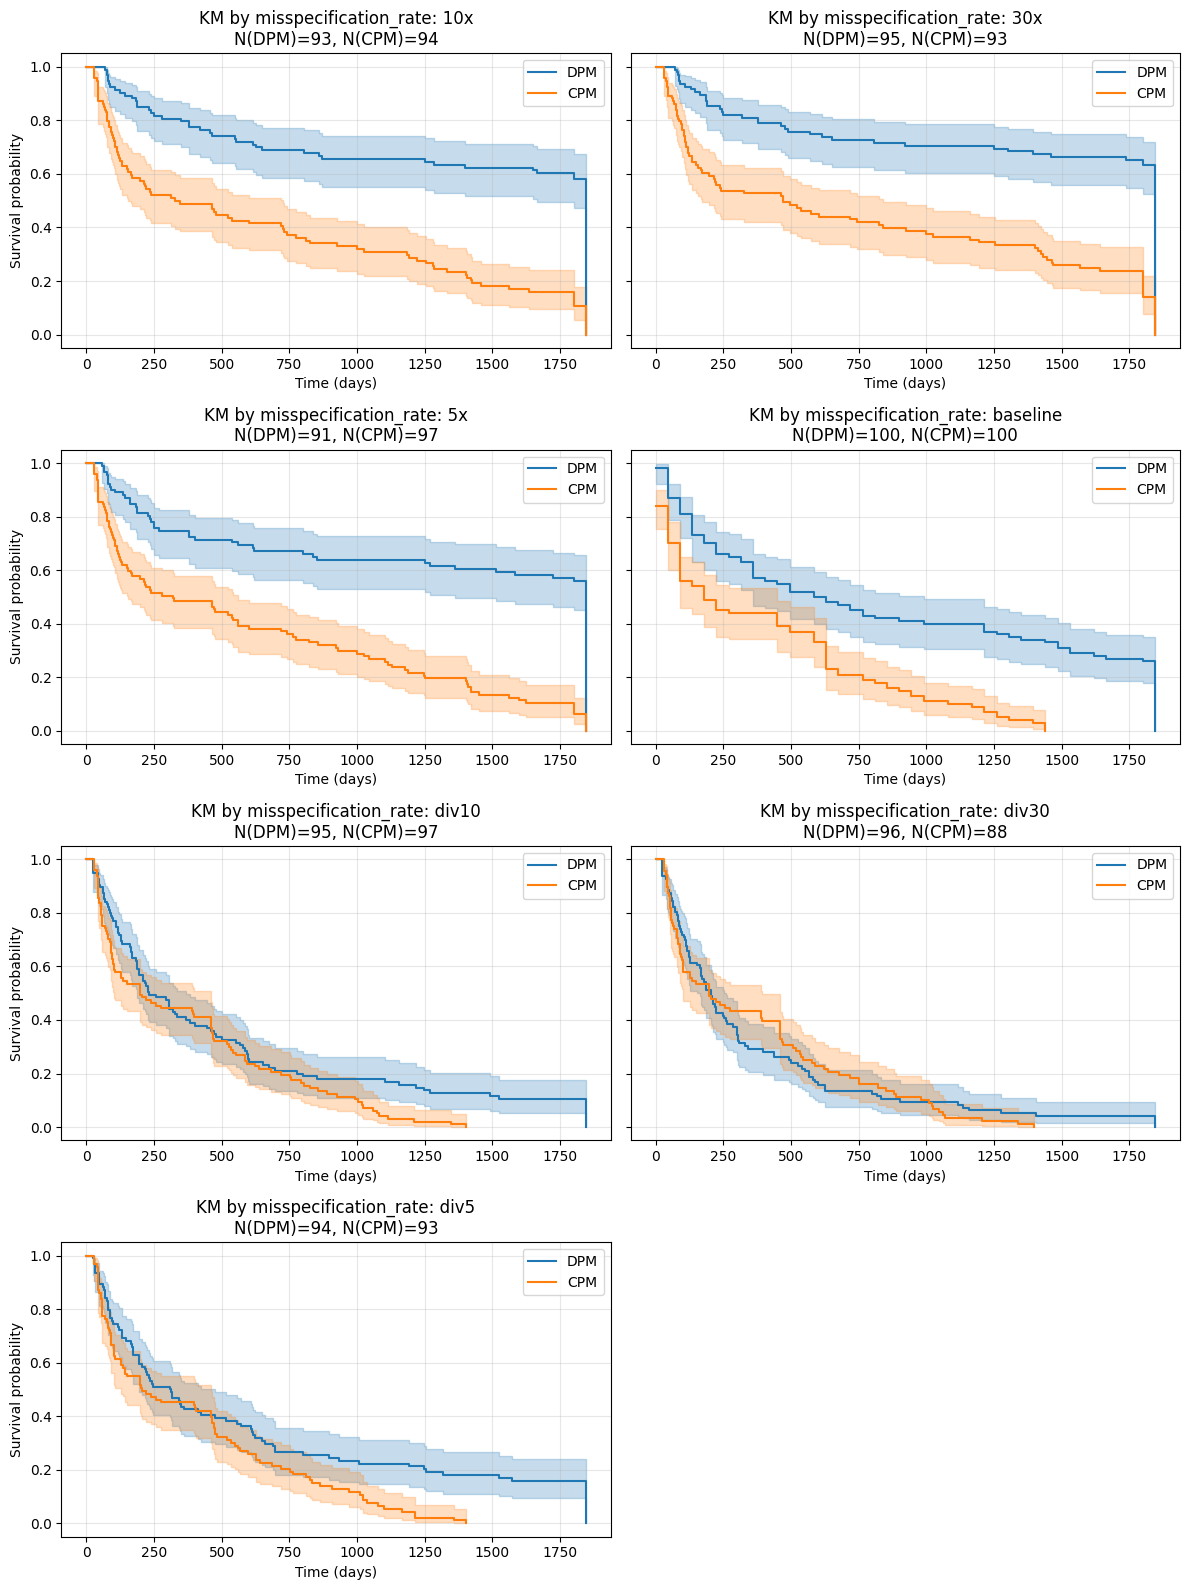

In [ ]:
dpm_arm = fetch_trial_arm(
    categories=["both_diff", "first_same_only", "second_same_only"],
    dosage_filter={"Drug1_Step1_CPM": 1},
    limit = 100,
    #param_filter={
    #    "S_pop": {"min": 3000000, "max": 4900000000},
    #    "g0": {"min": 0.01}  # only min
    #}
)
cpm_arm = fetch_trial_arm(
    categories=["both_same"],
    dosage_filter={"Drug1_Step1_CPM": 1},
    limit = 100,
    #param_filter={
    #    "S_pop": {"min": 3000000, "max": 4900000000},
    #    "g0": {"min": 0.01}  # only min
    #}
)
#dpm_arm.head(), cpm_arm.head()
plot_km_two_arms_by_rate(dpm_arm, cpm_arm, "misspecification_rate", "Survival_DPM", "Survival_CPM")
calc_hazard_ratio_two_arms_by_rate(dpm_arm, cpm_arm, arm_id="PopA")

(<Figure size 1200x1600 with 8 Axes>,
 [<Axes: title={'center': 'KM by misspecification_rate: 10x\nN(DPM)=24, N(CPM)=24'}, xlabel='Time (days)', ylabel='Survival probability'>,
  <Axes: title={'center': 'KM by misspecification_rate: 30x\nN(DPM)=22, N(CPM)=22'}, xlabel='Time (days)', ylabel='Survival probability'>,
  <Axes: title={'center': 'KM by misspecification_rate: 5x\nN(DPM)=24, N(CPM)=23'}, xlabel='Time (days)', ylabel='Survival probability'>,
  <Axes: title={'center': 'KM by misspecification_rate: baseline\nN(DPM)=25, N(CPM)=25'}, xlabel='Time (days)', ylabel='Survival probability'>,
  <Axes: title={'center': 'KM by misspecification_rate: div10\nN(DPM)=22, N(CPM)=22'}, xlabel='Time (days)', ylabel='Survival probability'>,
  <Axes: title={'center': 'KM by misspecification_rate: div30\nN(DPM)=24, N(CPM)=22'}, xlabel='Time (days)', ylabel='Survival probability'>,
  <Axes: title={'center': 'KM by misspecification_rate: div5\nN(DPM)=24, N(CPM)=23'}, xlabel='Time (days)', ylabel='Surv

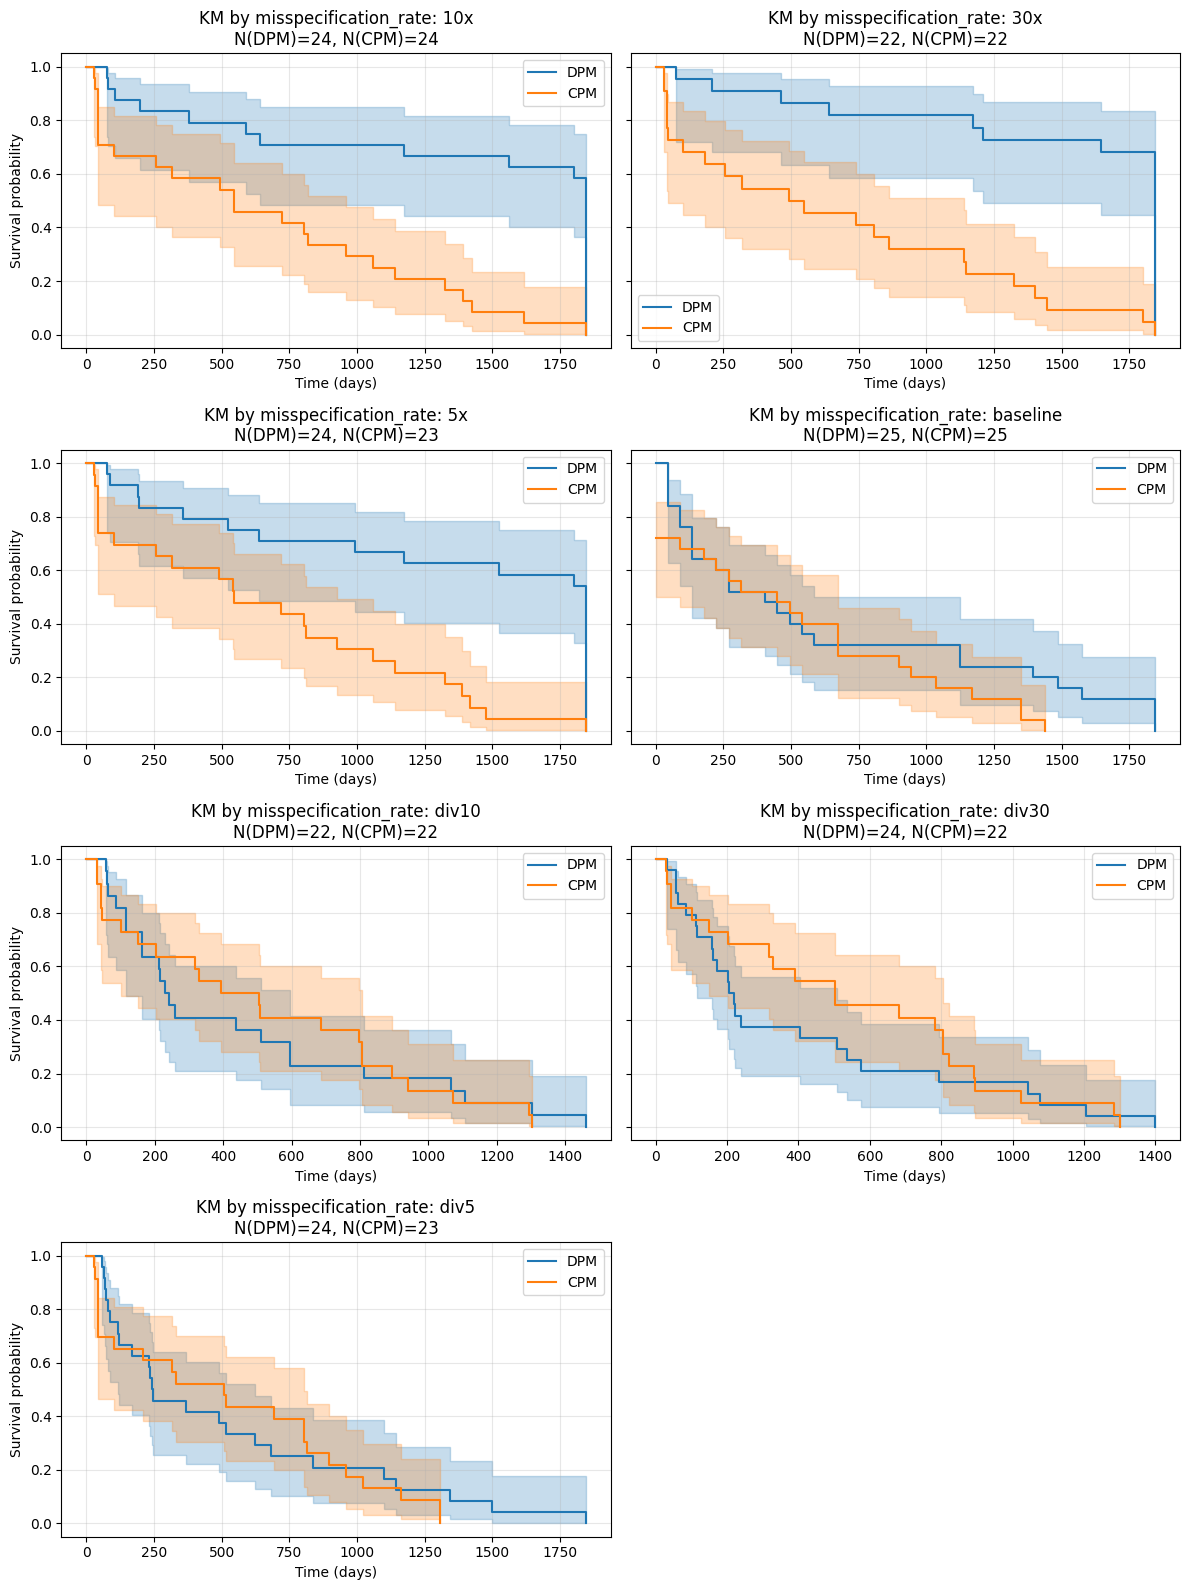

In [ ]:
plot_km_two_arms_by_rate(dpm_arm, cpm_arm, "misspecification_rate", "Survival_DPM", "Survival_CPM")

In [ ]:

calc_hazard_ratio_two_arms_by_rate(dpm_arm, cpm_arm, arm_id="PopA")



,misspecification_group,Comparison,N_DPM,N_CPM,HR,CI 95% lower,CI 95% upper,p,arm_id
0,10x,Survival_DPM vs Survival_CPM,24,24,0.285696,0.150345,0.542898,0.000131,PopA
1,30x,Survival_DPM vs Survival_CPM,22,22,0.240615,0.122967,0.470820,0.000032,PopA
2,5x,Survival_DPM vs Survival_CPM,24,23,0.312410,0.164213,0.594352,0.000392,PopA
3,baseline,Survival_DPM vs Survival_CPM,25,25,0.655345,0.359961,1.193120,0.166858,PopA
4,div10,Survival_DPM vs Survival_CPM,22,22,1.008276,0.551993,1.841729,0.978609,PopA
5,div30,Survival_DPM vs Survival_CPM,24,22,1.195764,0.661792,2.160576,0.553633,PopA
6,div5,Survival_DPM vs Survival_CPM,24,23,0.863823,0.475302,1.569929,0.631045,PopA
